In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.problem_setup import TestProblemsSetup

from fenics import Function, plot
from algorithms.rsvd_solvers import MatrixFreeRSVD
from algorithms.cg_solvers import DynamicalLowRankCG
from utils.metrics import SpaceIndexing, vec_to_matrix, matrix_to_vec

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

PROBLEMS = TestProblemsSetup(64).get_test_problems()

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
pb = PROBLEMS['II']
x = pb['x']

index = SpaceIndexing(pb['V_h'])
X = vec_to_matrix(x, index)

In [3]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)
f_list = []
for i in range(4):
    s, u, v = S[i], U[:, i], Vt[i, :]
    Xi = s * np.outer(u, v)

    f = Function(pb['V_h'])
    f.vector()[:] = matrix_to_vec(Xi, index)
    f_list.append(f)

../../figures/outer_product_II.png already exists


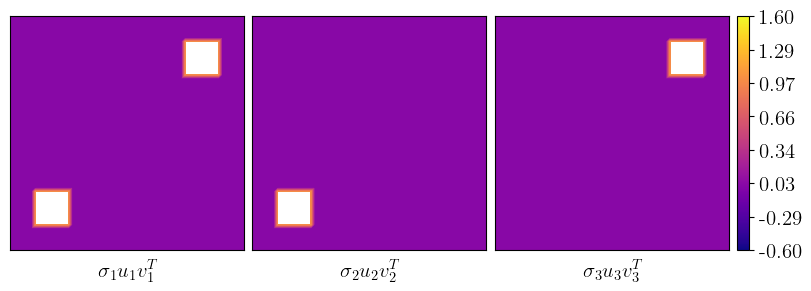

In [ ]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from utils.plotting import save_plot
import matplotlib.cm as cm


def plot_multiple_f(
        f_list, names=None, fig_name=None,
        vmin=-0.6, vmax=1.6,
        mid_text=None, 
    ):
    fig, axes = plt.subplots(1, 3, figsize=(8, 6), constrained_layout=True)
    axes = axes.flatten()

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    if names is None:
        names = ['' for _ in axes]

    for ax, func, name in zip(axes, f_list, names):
        plt.sca(ax)
        p = plot(func, title='', cmap='plasma', norm=norm)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(name, labelpad=6)

    sm = cm.ScalarMappable(norm=norm, cmap='plasma')
    sm.set_array([])

    ticks = np.linspace(vmin, vmax, 8)
    fig.colorbar(sm, ax=axes, format="%.2f", shrink=0.395, pad=0.012, ticks=ticks)

    if mid_text is not None:
        fig.text(
            0.1,
            0.1,
            r"$=$",
            fontsize=22,
            ha='center',
            va='center'
        )

    save_plot(fig_name)
    plt.show()


plot_multiple_f(
    f_list,
    names=[f"$\sigma_{i} u_{i} v_{i}^T$" for i in range(1, 4)],
    fig_name='outer_product_II'
)

---

**DLRA introduction figure**

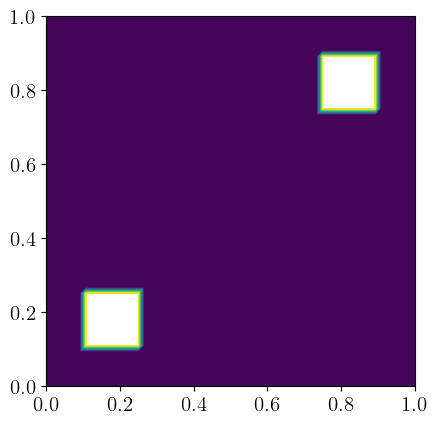

In [84]:
from utils.mesh_utils import get_square_mesh

n = 64
setup2 = TestProblemsSetup(n)

params = {
    'mesh': get_square_mesh,
    'n': n,
    'width': 0.15,
    'height': 0.15,
    'x0': [0.1, 0.9-0.15],
    'y0': [0.1, 0.9-0.15]
}


index = SpaceIndexing(pb['V_h'])
X = vec_to_matrix(pb['x'], index)
pb = setup2.problem_setup(params, compute_weights=False) 
plot(pb['f'])

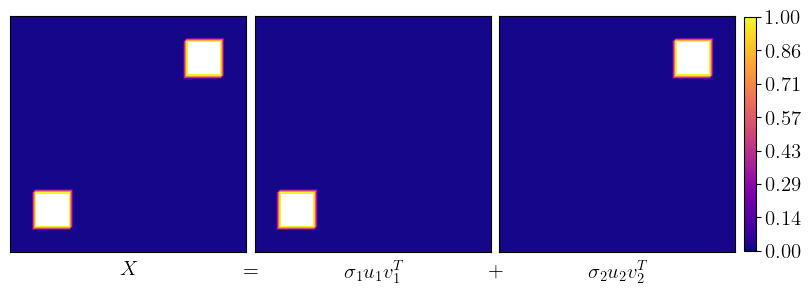

In [ ]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)
f_list = [pb['f']]

for i in range(2):
    s, u, v = S[i], U[:, i], Vt[i, :]
    Xi = s * np.outer(u, v)

    xi = matrix_to_vec(Xi, index)

    mask = np.where(xi > 0.99)[0]  # map 0.999... to 1 (better color)
    xi[mask] = 1.0
    
    f = Function(pb['V_h'])
    f.vector()[:] = xi
    f_list.append(f)


def plot_multiple_f(
        f_list, names=None, fig_name=None,
        vmin=-0.6, vmax=1.6,
        mid_text=None, 
    ):
    fig, axes = plt.subplots(1, 3, figsize=(8, 6), constrained_layout=True)
    axes = axes.flatten()

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    if names is None:
        names = ['' for _ in axes]

    for ax, func, name in zip(axes, f_list, names):
        plt.sca(ax)
        p = plot(func, title='', cmap='plasma', norm=norm)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(name, labelpad=6)

    sm = cm.ScalarMappable(norm=norm, cmap='plasma')
    sm.set_array([])

    ticks = np.linspace(vmin, vmax, 8)
    fig.colorbar(sm, ax=axes, format="%.2f", shrink=0.395, pad=0.012, ticks=ticks)

    if mid_text is not None:
        fig.text(
            0.307,  0.270, # x, y
            r"$=$", fontsize=15, ha='center', va='center'
        )
        fig.text(
            0.614,  0.270, # x, y
            r"$+$", fontsize=15, ha='center', va='center'
        )

    save_plot(fig_name)
    plt.show()

plot_multiple_f(
    f_list, vmin=0.0, vmax=1.0,
    names=["$X$", "$\sigma_1 u_1 v_1^T$", "$\sigma_2 u_2 v_2^T$"],
    mid_text='a'
    #fig_name='outer_product_II'
)

---
**DLRA Alternative Figure**

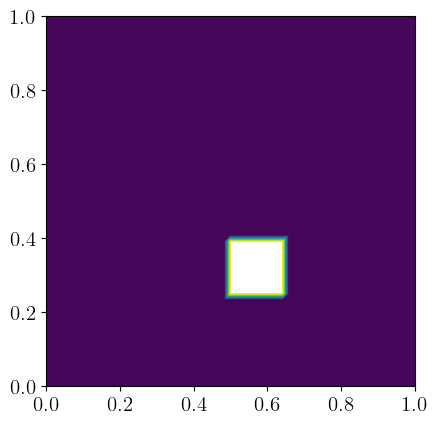

In [242]:
from utils.mesh_utils import get_square_mesh

n = 64
setup2 = TestProblemsSetup(n)

params = {
    'mesh': get_square_mesh,
    'n': n,
    'width': 0.15,
    'height': 0.15,
    'x0': [0.50],
    'y0': [0.25]
}


index = SpaceIndexing(pb['V_h'])
X = vec_to_matrix(pb['x'], index)
pb = setup2.problem_setup(params, compute_weights=False) 
plot(pb['f'])

In [243]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)
s, u, v = S[0], U[:, 0], Vt[0, :]

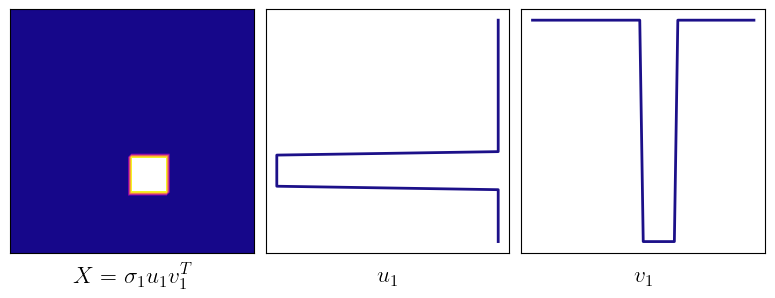

In [266]:
from dolfin import plot
import numpy as np

fs = 17

fig, axes = plt.subplots(1, 3, figsize=(8, 3))

# Left: source f on the mesh
plt.sca(axes[0])
plot(pb['f'], cmap='plasma')
axes[0].set_xlabel(r'$X = \sigma_1 u_1 v_1^T$', fontsize=fs, labelpad=7)
axes[0].set_box_aspect(1)
axes[0].set_xticks([])
axes[0].set_yticks([])

# Middle: u_1 — values on x-axis, index on y-axis (curve runs vertically)
axes[1].plot(u, np.arange(len(u)), c='#1c1089', lw=2.0)
axes[1].set_xlabel(r'$u_1$', fontsize=fs, labelpad=9)
axes[1].grid(True, alpha=.5)
axes[1].set_box_aspect(1)

# Right: v_1 — values on y-axis, index on x-axis (curve runs horizontally)
axes[2].plot(v, c='#1c1089', lw=2.0)
axes[2].set_xlabel(r'$v_1$', fontsize=fs, labelpad=9)
axes[2].grid(True, alpha=.5)
axes[2].set_box_aspect(1)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])


plt.tight_layout()
plt.subplots_adjust(wspace=0.05)
save_plot('low_rank_source')
